In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 📂 Chemin du fichier CSV
csv_path = r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv"
df = pd.read_csv(csv_path, sep=';', encoding='utf-8-sig')

# Conversion colonnes numériques
df['Montant'] = pd.to_numeric(df['Montant'].astype(str).str.replace(' ', '').str.replace(',', '.'), errors='coerce')
df['Taux'] = pd.to_numeric(df['Taux'].astype(str).str.replace(' ', '').str.replace(',', '.'), errors='coerce')
df['Nombre de Titres'] = pd.to_numeric(df['Nombre de Titres'].astype(str).str.replace(' ', ''), errors='coerce')
df['Echéance'] = pd.to_numeric(df['Echéance'].astype(str).str.replace(' ', ''), errors='coerce')

df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], errors='coerce', dayfirst=True)

df


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,2025-07-01,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.60
1,2025-07-01,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.50
2,2025-07-01,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.60
3,2025-07-01,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.60
4,2025-07-01,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.10
...,...,...,...,...,...,...,...
19840,2024-12-31,TN0008000812,"BTA 7,5% 13/12/2028",215.0,0.200,50.0,9.00
19841,2024-12-31,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5243.0,0.556,15.0,7.49
19842,2024-12-31,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28288.0,3.000,31.0,8.99
19843,2024-12-31,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48701.0,5.165,31.0,8.99


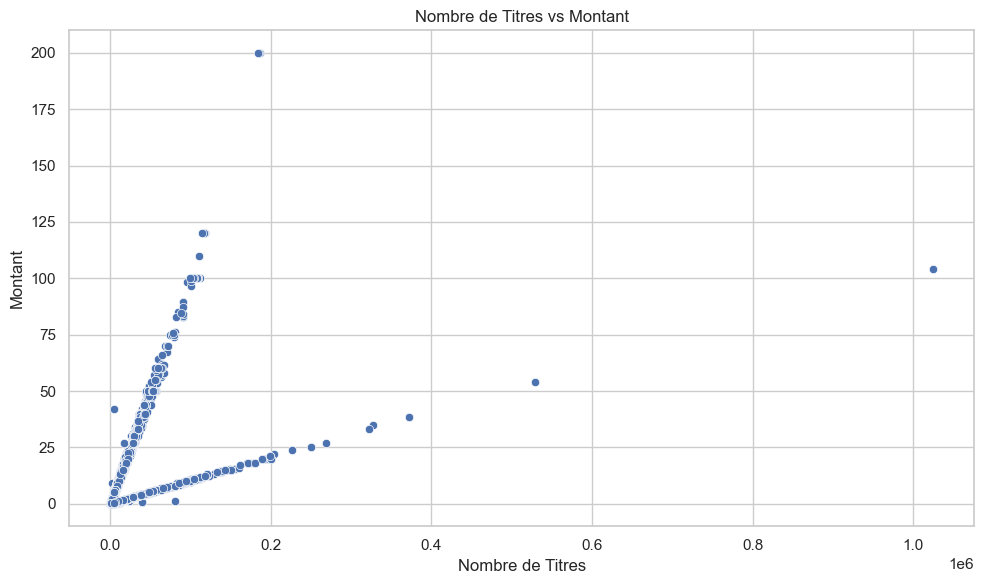

In [2]:
sns.scatterplot(data=df, x='Nombre de Titres', y='Montant')
plt.title("Nombre de Titres vs Montant")
plt.tight_layout()
plt.show()


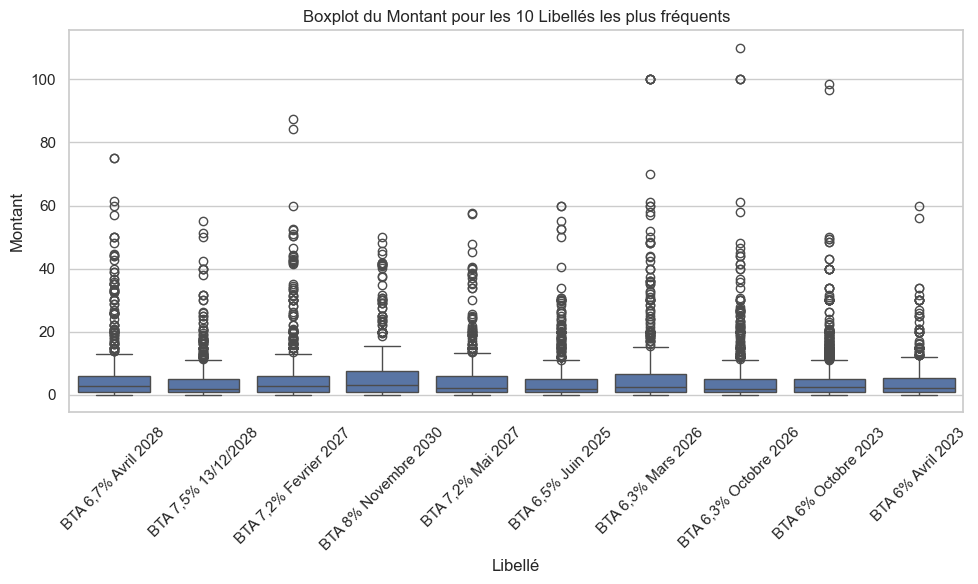

In [6]:
top_labels = df['Libellé'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['Libellé'].isin(top_labels)], x='Libellé', y='Montant')
plt.xticks(rotation=45)
plt.title("Boxplot du Montant pour les 10 Libellés les plus fréquents")
plt.tight_layout()
plt.show()


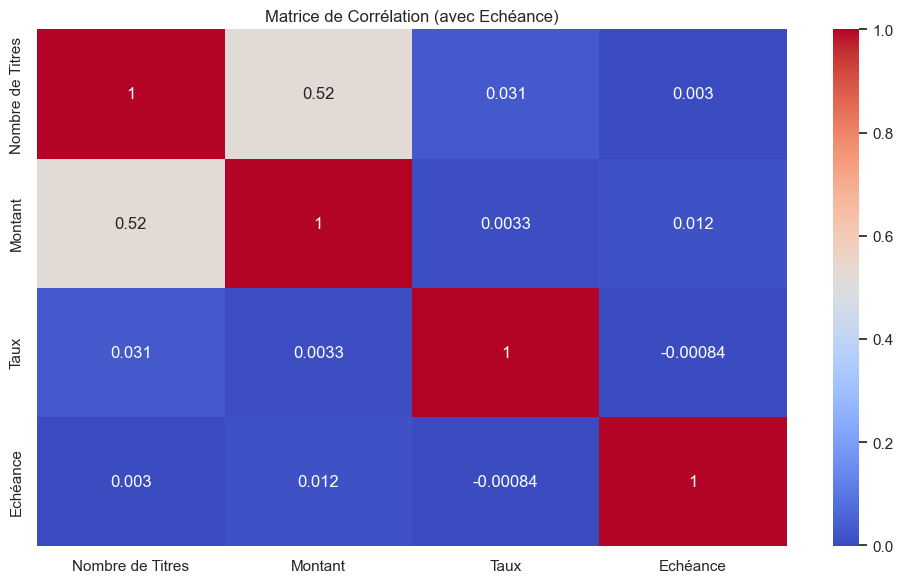

In [7]:
sns.heatmap(df[['Nombre de Titres', 'Montant', 'Taux', 'Echéance']].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de Corrélation (avec Echéance)")
plt.tight_layout()
plt.show()


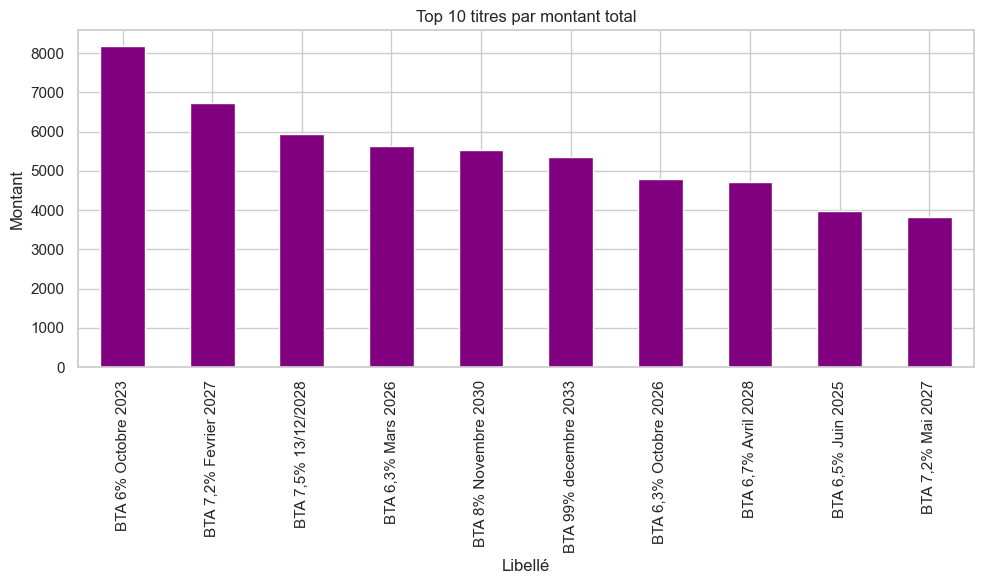

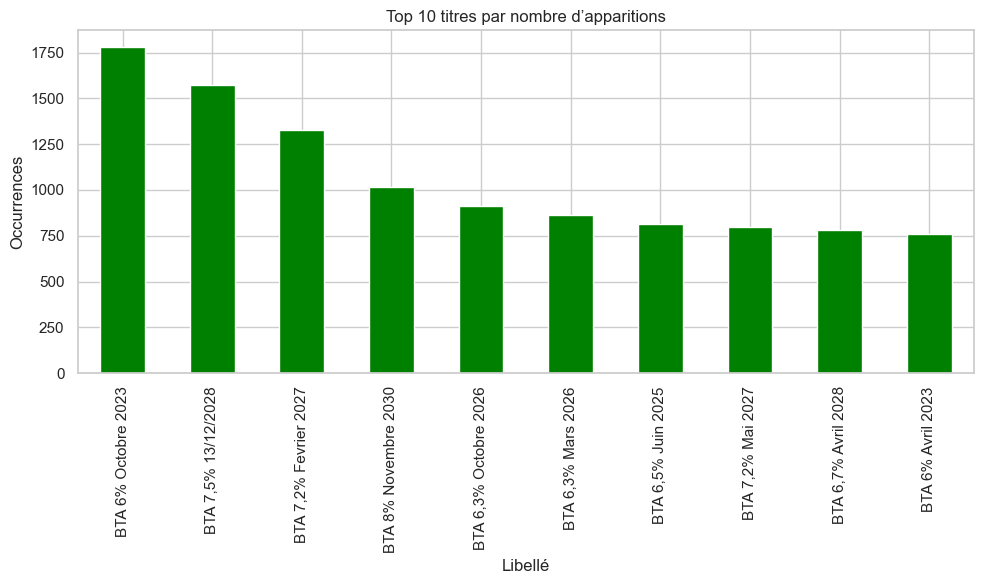

In [8]:
# a) Par montant total
df.groupby('Libellé')['Montant'].sum().nlargest(10).plot(kind='bar', color='purple')
plt.title("Top 10 titres par montant total")
plt.ylabel("Montant")
plt.tight_layout()
plt.show()

# b) Par nombre de lignes
df['Libellé'].value_counts().nlargest(10).plot(kind='bar', color='green')
plt.title("Top 10 titres par nombre d’apparitions")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()


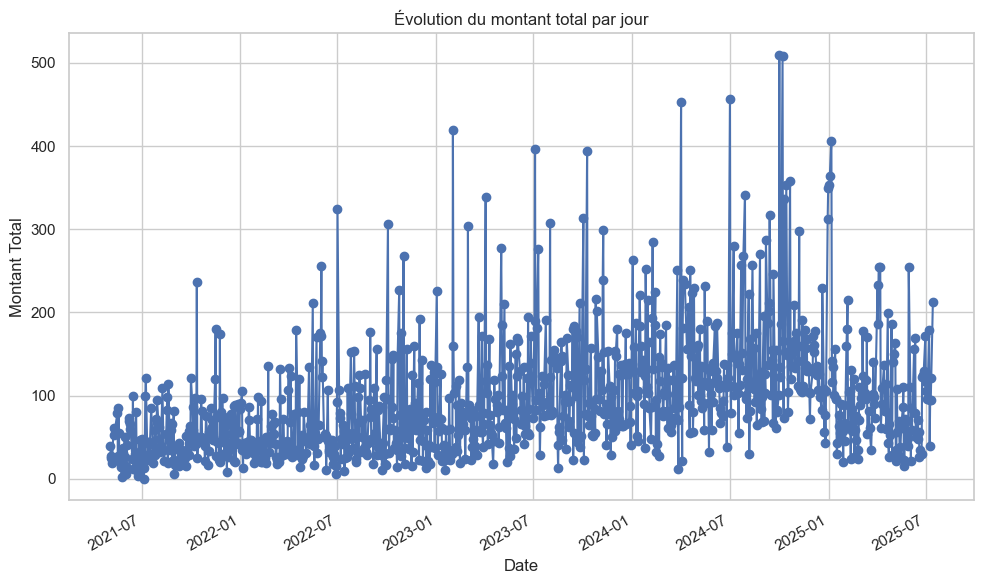

In [9]:
df.groupby('dataloadingdate')['Montant'].sum().plot(kind='line', marker='o')
plt.title("Évolution du montant total par jour")
plt.xlabel("Date")
plt.ylabel("Montant Total")
plt.tight_layout()
plt.show()


C:\Users\zizou\AppData\Local\Temp\ipykernel_26300\3132737526.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Classe Taux')['Montant'].sum().plot(kind='bar', color='coral')


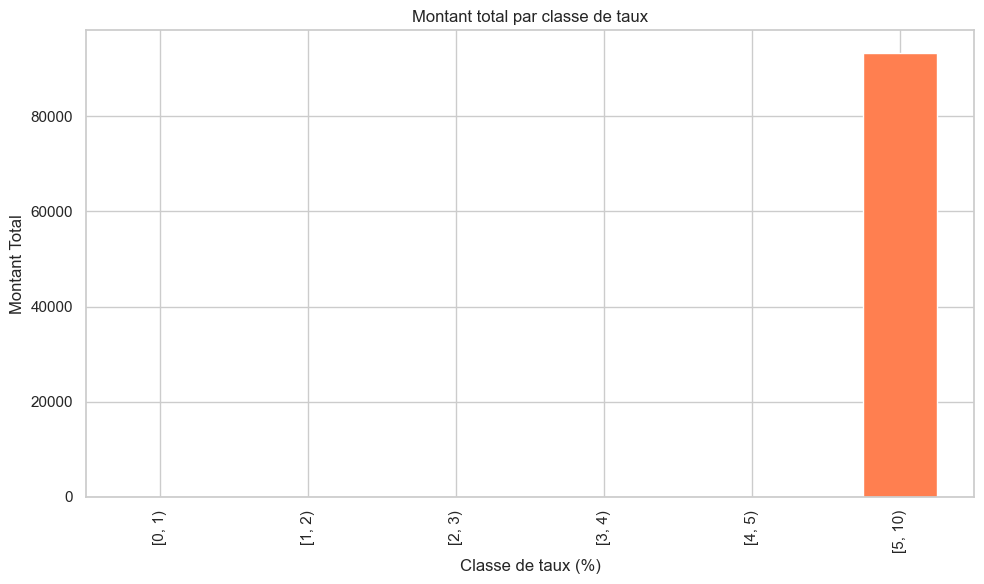

In [10]:
df['Classe Taux'] = pd.cut(df['Taux'], bins=[0, 1, 2, 3, 4, 5, 10], right=False)
df.groupby('Classe Taux')['Montant'].sum().plot(kind='bar', color='coral')
plt.title("Montant total par classe de taux")
plt.xlabel("Classe de taux (%)")
plt.ylabel("Montant Total")
plt.tight_layout()
plt.show()


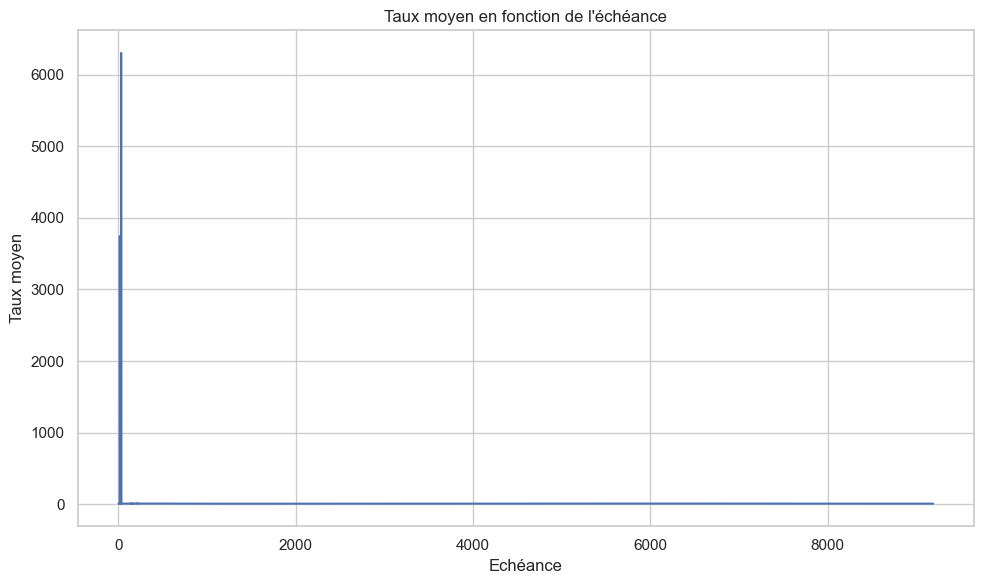

In [11]:
df.groupby('Echéance')['Taux'].mean().plot(kind='line')
plt.title("Taux moyen en fonction de l'échéance")
plt.xlabel("Echéance")
plt.ylabel("Taux moyen")
plt.tight_layout()
plt.show()


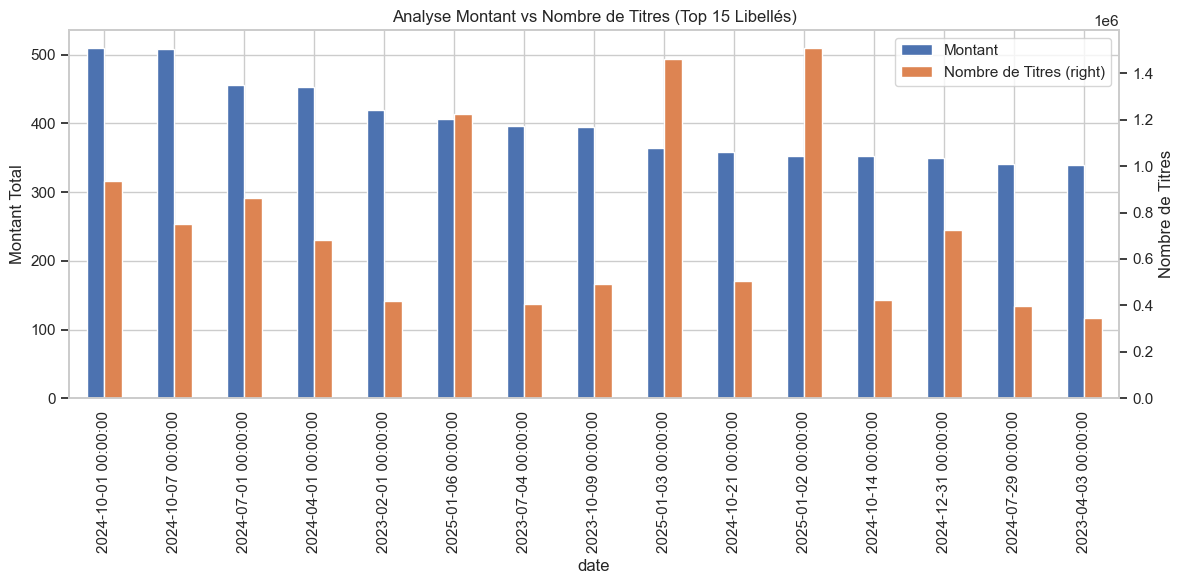

In [13]:
# Cellule 12 : Analyse Montant vs Nombre de Titres (barres empilées par Libellé)

# On groupe par Libellé, en sommant Montant et Nombre de Titres
df_grouped = df.groupby('dataloadingdate').agg({
    'Montant': 'sum',
    'Nombre de Titres': 'sum'
}).sort_values('Montant', ascending=False).head(15)  # Top 15 Libellés pour lisibilité

ax = df_grouped.plot(kind='bar', secondary_y='Nombre de Titres', figsize=(12,6))

ax.set_xlabel("date")
ax.set_ylabel("Montant Total")
ax.right_ax.set_ylabel("Nombre de Titres")

plt.title("Analyse Montant vs Nombre de Titres (Top 15 Libellés)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
